# IoU, GIoU, DIoU, CIoU and mAP

Intersection over Union (IoU) is the **foundation** of object detection evaluation. Every concept — anchor assignment, NMS, mAP — builds on IoU.

**History**: The measure originates from the **Jaccard Index** (Paul Jaccard, 1901) used in ecology to compare species overlap. It was adopted into computer vision by the **Pascal VOC challenge** (Everingham et al., 2010), which defined a detection as correct if IoU ≥ 0.5 with any ground-truth box. Every modern benchmark (COCO, Open Images, BDD100K) inherits this definition.

## 1. IoU (Jaccard Index)

<img src='img/iou_equation.png' width='500'/>

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{Intersection Area}}{\text{Area}(A) + \text{Area}(B) - \text{Intersection Area}}$$

**Properties**:
- Range: [0, 1] — 0 = no overlap, 1 = perfect match
- **Scale-invariant**: a 10×10 box vs 10×10 GT gives same IoU as 100×100 vs 100×100 (if perfectly aligned)
- **Threshold rules** (Pascal VOC / COCO):
  - IoU ≥ 0.5 → True Positive (TP)
  - IoU < 0.5 → False Positive (FP)
  - Unmatched GT → False Negative (FN)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe

# ── Basic IoU (numpy) ────────────────────────────────────────────────────────
def iou_numpy(box1, box2):
    """
    Compute IoU between two boxes [x1, y1, x2, y2].
    Works on single boxes or arrays of shape (N, 4).
    """
    inter_x1 = np.maximum(box1[..., 0], box2[..., 0])
    inter_y1 = np.maximum(box1[..., 1], box2[..., 1])
    inter_x2 = np.minimum(box1[..., 2], box2[..., 2])
    inter_y2 = np.minimum(box1[..., 3], box2[..., 3])

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    area1 = (box1[..., 2] - box1[..., 0]) * (box1[..., 3] - box1[..., 1])
    area2 = (box2[..., 2] - box2[..., 0]) * (box2[..., 3] - box2[..., 1])
    union = area1 + area2 - intersection

    return intersection / (union + 1e-6)


# Demo: 3 cases — perfect, partial, no overlap
gt   = np.array([1.0, 1.0, 4.0, 4.0])  # ground truth box
pred_perfect = np.array([1.0, 1.0, 4.0, 4.0])
pred_partial = np.array([2.0, 2.0, 5.0, 5.0])
pred_none    = np.array([5.0, 5.0, 7.0, 7.0])

for name, pred in [('Perfect match', pred_perfect),
                   ('Partial overlap', pred_partial),
                   ('No overlap', pred_none)]:
    v = iou_numpy(gt, pred)
    print(f'{name:20s}: IoU = {v:.4f}')

Perfect match       : IoU = 1.0000
Partial overlap     : IoU = 0.2857
No overlap          : IoU = 0.0000


## Visualizing IoU for Different Overlap Cases

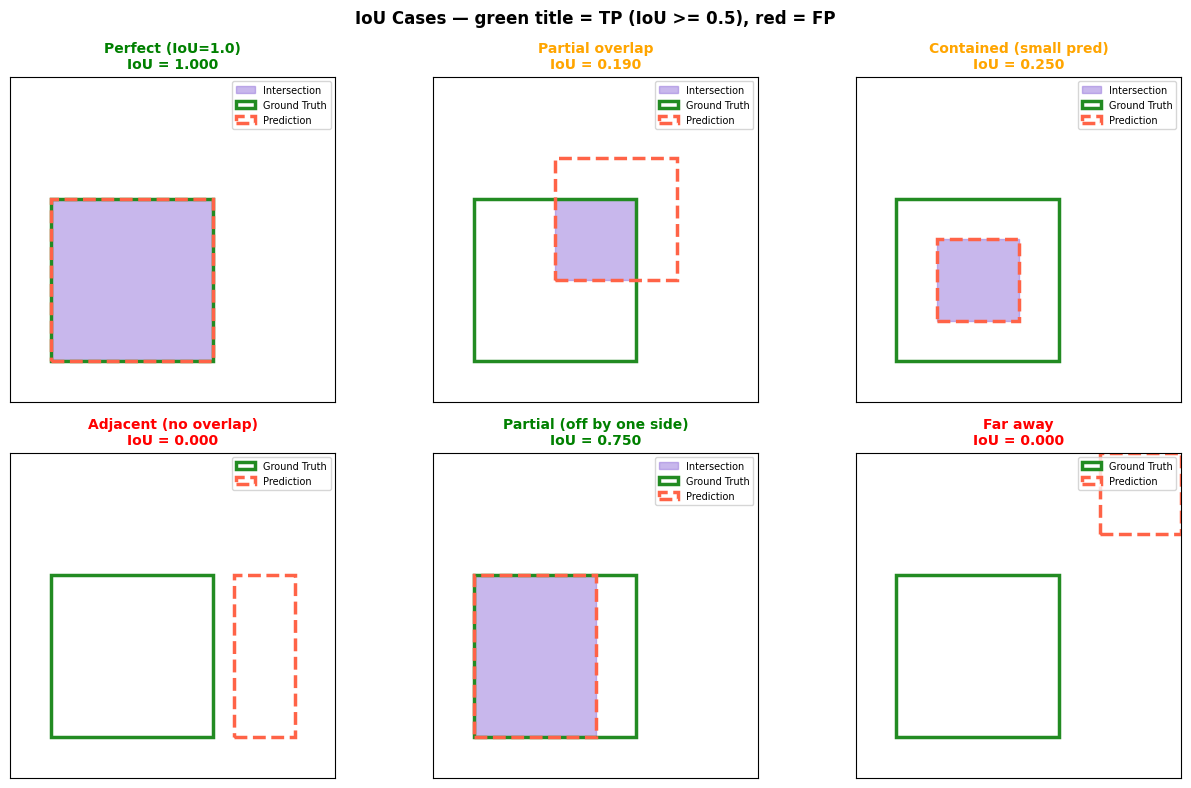

In [2]:
def draw_iou(ax, gt, pred, title):
    ax.set_xlim(0, 8); ax.set_ylim(0, 8)
    ax.set_aspect('equal')

    # Fill intersection
    ix1 = max(gt[0], pred[0]); iy1 = max(gt[1], pred[1])
    ix2 = min(gt[2], pred[2]); iy2 = min(gt[3], pred[3])
    if ix2 > ix1 and iy2 > iy1:
        ax.add_patch(patches.Rectangle((ix1,iy1), ix2-ix1, iy2-iy1,
            color='mediumpurple', alpha=0.5, label='Intersection'))

    ax.add_patch(patches.Rectangle((gt[0],gt[1]), gt[2]-gt[0], gt[3]-gt[1],
        fill=False, edgecolor='forestgreen', lw=2.5, label='Ground Truth'))
    ax.add_patch(patches.Rectangle((pred[0],pred[1]), pred[2]-pred[0], pred[3]-pred[1],
        fill=False, edgecolor='tomato', lw=2.5, linestyle='--', label='Prediction'))

    iou_val = iou_numpy(np.array(gt), np.array(pred))
    color = 'green' if iou_val >= 0.5 else ('orange' if iou_val > 0 else 'red')
    ax.set_title(f'{title}\nIoU = {iou_val:.3f}', fontsize=10,
                 color=color, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

cases = [
    ([1,1,5,5], [1,1,5,5],   'Perfect (IoU=1.0)'),
    ([1,1,5,5], [3,3,6,6],   'Partial overlap'),
    ([1,1,5,5], [2,2,4,4],   'Contained (small pred)'),
    ([1,1,5,5], [5.5,1,7,5], 'Adjacent (no overlap)'),
    ([1,1,5,5], [1,1,4,5],   'Partial (off by one side)'),
    ([1,1,5,5], [6,6,8,8],   'Far away'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (gt, pred, title) in zip(axes.flat, cases):
    draw_iou(ax, gt, pred, title)
plt.suptitle('IoU Cases — green title = TP (IoU >= 0.5), red = FP', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Batch IoU Matrix

In practice (NMS, anchor assignment, mAP matching) we need IoU between **all pairs** of N predicted boxes and M ground-truth boxes simultaneously — a (N, M) matrix.

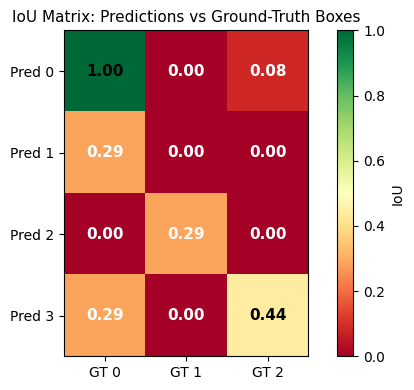

Note: torchvision.ops.box_iou does the same thing efficiently.


/Users/guntsv/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


torchvision result matches: True


In [3]:
def box_iou_matrix(boxes1, boxes2):
    """
    Compute pairwise IoU between all boxes.
    boxes1: (N, 4), boxes2: (M, 4)  →  returns (N, M)
    """
    # Expand for broadcasting
    b1 = boxes1[:, None, :]   # (N, 1, 4)
    b2 = boxes2[None, :, :]   # (1, M, 4)

    inter_x1 = torch.maximum(b1[..., 0], b2[..., 0])
    inter_y1 = torch.maximum(b1[..., 1], b2[..., 1])
    inter_x2 = torch.minimum(b1[..., 2], b2[..., 2])
    inter_y2 = torch.minimum(b1[..., 3], b2[..., 3])

    inter = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    area1 = (b1[..., 2] - b1[..., 0]) * (b1[..., 3] - b1[..., 1])
    area2 = (b2[..., 2] - b2[..., 0]) * (b2[..., 3] - b2[..., 1])
    union = area1 + area2 - inter

    return inter / (union + 1e-6)  # (N, M)


# 4 predictions, 3 ground-truth boxes
preds = torch.tensor([[1.,1.,4.,4.],[2.,2.,5.,5.],[6.,6.,9.,9.],[0.,0.,3.,3.]])
gts   = torch.tensor([[1.,1.,4.,4.],[5.,5.,8.,8.],[0.,0.,2.,2.]])

iou_mat = box_iou_matrix(preds, gts)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(iou_mat.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_yticks(range(4))
ax.set_xticklabels([f'GT {i}' for i in range(3)])
ax.set_yticklabels([f'Pred {i}' for i in range(4)])
for i in range(4):
    for j in range(3):
        v = iou_mat[i,j].item()
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if v < 0.4 else 'black')
plt.colorbar(im, ax=ax, label='IoU')
ax.set_title('IoU Matrix: Predictions vs Ground-Truth Boxes', fontsize=11)
plt.tight_layout(); plt.show()
print('Note: torchvision.ops.box_iou does the same thing efficiently.')
from torchvision.ops import box_iou
print('torchvision result matches:', torch.allclose(box_iou(preds, gts), iou_mat, atol=1e-5))

## 2. Why Standard IoU Fails as a Loss Function

When using IoU directly as a loss ($L = 1 - \text{IoU}$), two critical failure modes arise:

**Problem 1 — Zero gradient when boxes don't overlap**:
If predicted box and GT have IoU = 0 (no intersection), the gradient of $1 - \text{IoU}$ is exactly 0. The loss is flat — the optimizer has no direction to move.

**Problem 2 — Same IoU, different geometry**:
A box that's the wrong shape but coincidentally overlaps the same area gets the same loss as a correct box. The loss doesn't distinguish these cases.

## GIoU: Generalized IoU (Rezatofighi et al., CVPR 2019)

$$\text{GIoU} = \text{IoU} - \frac{|C \setminus (A \cup B)|}{|C|}$$

where $C$ is the **smallest enclosing box** of both A and B.

- When boxes overlap: GIoU ≈ IoU (same behavior)
- When boxes **don't overlap**: GIoU penalizes based on how far apart they are via the enclosing box
- Range: [-1, 1] (vs [0, 1] for IoU)
- **Loss**: $L_{GIoU} = 1 - \text{GIoU}$, range [0, 2]

In [4]:
def giou(box1, box2):
    """
    Generalized IoU. Inputs: (N, 4) tensors [x1,y1,x2,y2].
    Returns: (N,) GIoU values in [-1, 1].
    """
    # Intersection
    ix1 = torch.maximum(box1[:, 0], box2[:, 0])
    iy1 = torch.maximum(box1[:, 1], box2[:, 1])
    ix2 = torch.minimum(box1[:, 2], box2[:, 2])
    iy2 = torch.minimum(box1[:, 3], box2[:, 3])
    inter = (ix2 - ix1).clamp(0) * (iy2 - iy1).clamp(0)

    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    union = area1 + area2 - inter
    iou_val = inter / (union + 1e-6)

    # Smallest enclosing box C
    cx1 = torch.minimum(box1[:, 0], box2[:, 0])
    cy1 = torch.minimum(box1[:, 1], box2[:, 1])
    cx2 = torch.maximum(box1[:, 2], box2[:, 2])
    cy2 = torch.maximum(box1[:, 3], box2[:, 3])
    area_c = (cx2 - cx1) * (cy2 - cy1)

    giou_val = iou_val - (area_c - union) / (area_c + 1e-6)
    return giou_val


# Compare: boxes that don't overlap
b1 = torch.tensor([[1., 1., 3., 3.]])
b2 = torch.tensor([[5., 5., 7., 7.]])
b3 = torch.tensor([[4., 1., 6., 3.]])

print(f'No overlap (far diag): IoU = {box_iou_matrix(b1, b2)[0,0]:.4f}, GIoU = {giou(b1, b2)[0]:.4f}')
print(f'No overlap (adjacent): IoU = {box_iou_matrix(b1, b3)[0,0]:.4f}, GIoU = {giou(b1, b3)[0]:.4f}')
print()
print('GIoU is more negative when boxes are farther apart → provides gradient signal even with no overlap')

No overlap (far diag): IoU = 0.0000, GIoU = -0.7778
No overlap (adjacent): IoU = 0.0000, GIoU = -0.2000

GIoU is more negative when boxes are farther apart → provides gradient signal even with no overlap


## 3. DIoU: Distance IoU (Zheng et al., AAAI 2020)

GIoU still converges slowly when one box is inside another (enclosing box = union → GIoU ≈ IoU). DIoU adds a **center-point distance** penalty:

$$\text{DIoU} = \text{IoU} - \frac{\rho^2(b, b^{gt})}{c^2}$$

where:
- $\rho^2(b, b^{gt})$ = squared Euclidean distance between the **centers** of pred and GT
- $c^2$ = squared diagonal of the **smallest enclosing box**

**Advantages over GIoU**:
- Faster convergence (minimizes center distance directly)
- Works well even when one box is inside another
- Used as the NMS criterion in **DIoU-NMS** (better than standard IoU-NMS for crowded scenes)

In [5]:
def diou(box1, box2):
    """
    Distance IoU. Inputs: (N, 4) [x1,y1,x2,y2]. Returns: (N,) DIoU.
    """
    ix1 = torch.maximum(box1[:,0], box2[:,0])
    iy1 = torch.maximum(box1[:,1], box2[:,1])
    ix2 = torch.minimum(box1[:,2], box2[:,2])
    iy2 = torch.minimum(box1[:,3], box2[:,3])
    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)

    area1 = (box1[:,2]-box1[:,0]) * (box1[:,3]-box1[:,1])
    area2 = (box2[:,2]-box2[:,0]) * (box2[:,3]-box2[:,1])
    union = area1 + area2 - inter
    iou_val = inter / (union + 1e-6)

    # Center distance
    cx1 = (box1[:,0] + box1[:,2]) / 2;  cy1 = (box1[:,1] + box1[:,3]) / 2
    cx2 = (box2[:,0] + box2[:,2]) / 2;  cy2 = (box2[:,1] + box2[:,3]) / 2
    rho2 = (cx1-cx2)**2 + (cy1-cy2)**2   # squared center distance

    # Diagonal of enclosing box
    encl_x1 = torch.minimum(box1[:,0], box2[:,0])
    encl_y1 = torch.minimum(box1[:,1], box2[:,1])
    encl_x2 = torch.maximum(box1[:,2], box2[:,2])
    encl_y2 = torch.maximum(box1[:,3], box2[:,3])
    c2 = (encl_x2-encl_x1)**2 + (encl_y2-encl_y1)**2  # squared diagonal

    return iou_val - rho2 / (c2 + 1e-6)


# Demo: same IoU, different center positions
gt_box = torch.tensor([[2., 2., 6., 6.]])
pred_centered = torch.tensor([[2.5, 2.5, 5.5, 5.5]])  # centered, inside
pred_shifted  = torch.tensor([[0.5, 0.5, 4.5, 4.5]])  # shifted, same IoU

for name, pred in [('Centered pred', pred_centered), ('Shifted pred', pred_shifted)]:
    iou_v  = box_iou_matrix(gt_box, pred)[0,0].item()
    giou_v = giou(gt_box, pred)[0].item()
    diou_v = diou(gt_box, pred)[0].item()
    print(f'{name:20s}: IoU={iou_v:.3f}  GIoU={giou_v:.3f}  DIoU={diou_v:.3f}')
print()
print('DIoU distinguishes them even when IoU is the same — it sees center distance!')

Centered pred       : IoU=0.562  GIoU=0.562  DIoU=0.562
Shifted pred        : IoU=0.243  GIoU=0.094  DIoU=0.168

DIoU distinguishes them even when IoU is the same — it sees center distance!


## 4. CIoU: Complete IoU (Zheng et al., AAAI 2020)

CIoU adds an **aspect ratio consistency** term on top of DIoU:

$$\text{CIoU} = \text{IoU} - \frac{\rho^2(b, b^{gt})}{c^2} - \alpha v$$

where:
$$v = \frac{4}{\pi^2}\left(\arctan\frac{w^{gt}}{h^{gt}} - \arctan\frac{w}{h}\right)^2 \quad\quad \alpha = \frac{v}{(1-\text{IoU})+v}$$

$v$ measures the **consistency of aspect ratio** — if pred and GT have the same shape (even if scaled differently), $v = 0$.

**CIoU addresses three geometric factors simultaneously**:
1. **Overlap area** (IoU term)
2. **Center distance** (DIoU term)
3. **Aspect ratio** (v term)

CIoU is the default box regression loss in **YOLOv5, YOLOv7, YOLOv8, RT-DETR**.

In [6]:
import math

def ciou(box1, box2, eps=1e-7):
    """
    Complete IoU loss. Inputs: (N, 4) [x1,y1,x2,y2]. Returns: (N,) CIoU.
    """
    ix1 = torch.maximum(box1[:,0], box2[:,0])
    iy1 = torch.maximum(box1[:,1], box2[:,1])
    ix2 = torch.minimum(box1[:,2], box2[:,2])
    iy2 = torch.minimum(box1[:,3], box2[:,3])
    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)

    w1 = box1[:,2]-box1[:,0]; h1 = box1[:,3]-box1[:,1]
    w2 = box2[:,2]-box2[:,0]; h2 = box2[:,3]-box2[:,1]
    area1 = w1 * h1; area2 = w2 * h2
    union = area1 + area2 - inter
    iou_val = inter / (union + eps)

    # Center distance
    cx1=(box1[:,0]+box1[:,2])/2; cy1=(box1[:,1]+box1[:,3])/2
    cx2=(box2[:,0]+box2[:,2])/2; cy2=(box2[:,1]+box2[:,3])/2
    rho2 = (cx1-cx2)**2 + (cy1-cy2)**2

    # Enclosing box diagonal
    ex1=torch.minimum(box1[:,0],box2[:,0]); ey1=torch.minimum(box1[:,1],box2[:,1])
    ex2=torch.maximum(box1[:,2],box2[:,2]); ey2=torch.maximum(box1[:,3],box2[:,3])
    c2 = (ex2-ex1)**2 + (ey2-ey1)**2

    # Aspect ratio consistency v
    v = (4 / (math.pi**2)) * (torch.atan(w2/(h2+eps)) - torch.atan(w1/(h1+eps)))**2
    with torch.no_grad():
        alpha = v / (1 - iou_val + v + eps)

    return iou_val - rho2/(c2+eps) - alpha*v


# Summary comparison
gt_b = torch.tensor([[2., 2., 6., 5.]])  # 4x3 box
cases_ciou = [
    ('Identical',        torch.tensor([[2., 2., 6., 5.]])),
    ('Same ratio, bigger',torch.tensor([[1., 1., 7., 5.5]])),
    ('Wrong ratio',      torch.tensor([[2., 2., 5., 6.]])),   # tall instead of wide
    ('Shifted, same AR', torch.tensor([[3., 3., 7., 6.]])),
    ('No overlap',       torch.tensor([[8., 8.,10.,10.]])),
]
print(f'{"Case":25s}  IoU     GIoU    DIoU    CIoU')
print('-' * 65)
for name, pred in cases_ciou:
    iou_v  = box_iou_matrix(gt_b, pred)[0,0].item()
    giou_v = giou(gt_b, pred)[0].item()
    diou_v = diou(gt_b, pred)[0].item()
    ciou_v = ciou(gt_b, pred)[0].item()
    print(f'{name:25s}  {iou_v:6.3f}  {giou_v:6.3f}  {diou_v:6.3f}  {ciou_v:6.3f}')

Case                       IoU     GIoU    DIoU    CIoU
-----------------------------------------------------------------
Identical                   1.000   1.000   1.000   1.000
Same ratio, bigger          0.444   0.444   0.443   0.443
Wrong ratio                 0.600   0.537   0.584   0.582
Shifted, same AR            0.333   0.233   0.285   0.285
No overlap                  0.000  -0.750  -0.432  -0.432


## IoU Family Visual Comparison

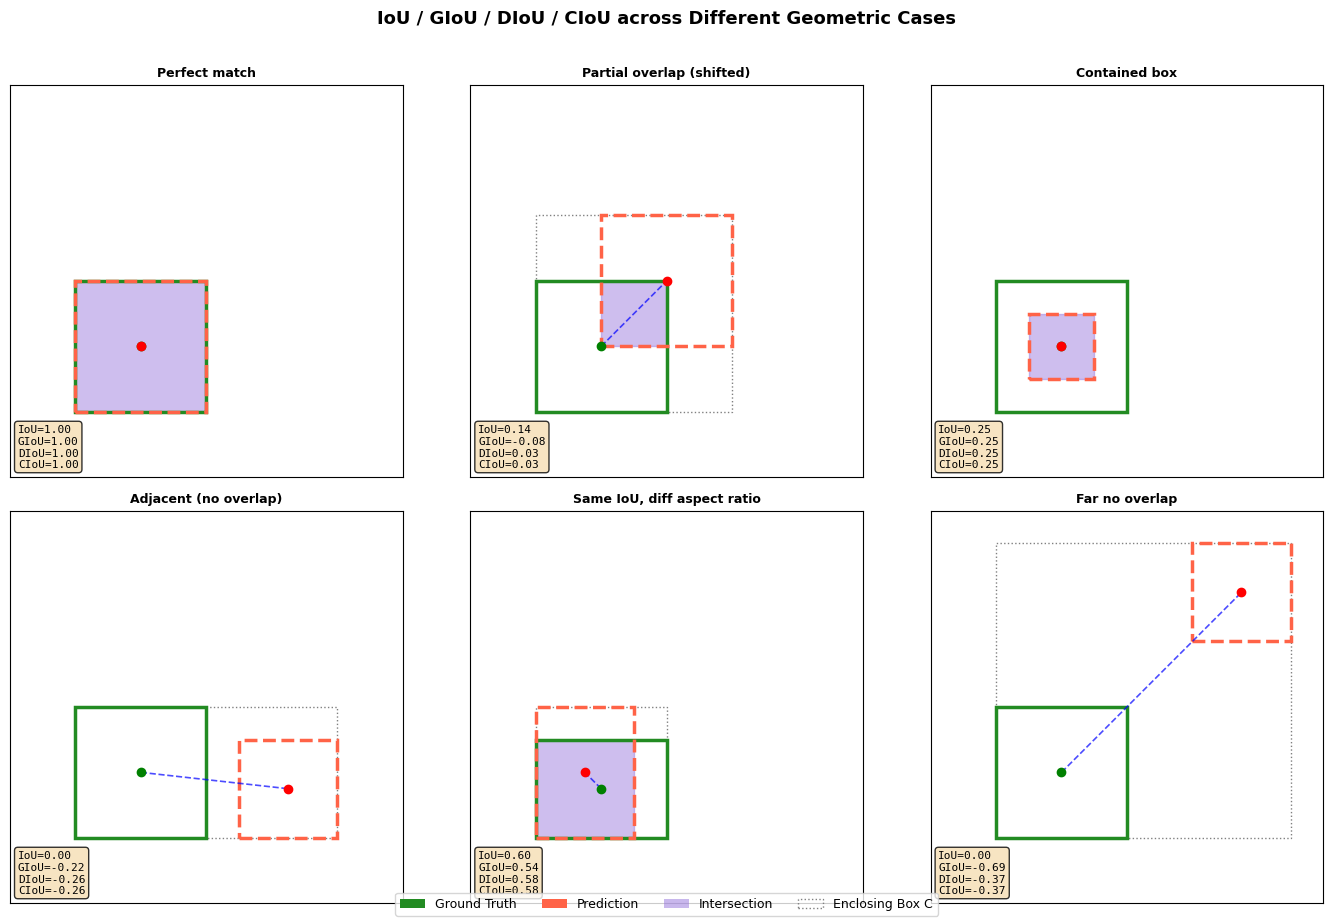

In [7]:
def draw_iou_variant(ax, gt, pred, title, score_fn_names):
    ax.set_xlim(-1, 11); ax.set_ylim(-1, 11); ax.set_aspect('equal')

    gt_t   = torch.tensor([gt],   dtype=torch.float32)
    pred_t = torch.tensor([pred], dtype=torch.float32)

    # Enclosing box
    ex1=min(gt[0],pred[0]); ey1=min(gt[1],pred[1])
    ex2=max(gt[2],pred[2]); ey2=max(gt[3],pred[3])
    ax.add_patch(patches.Rectangle((ex1,ey1),ex2-ex1,ey2-ey1,
        fill=False,edgecolor='gray',lw=1,linestyle=':',label='Enclosing C'))

    # Intersection fill
    ix1=max(gt[0],pred[0]); iy1=max(gt[1],pred[1])
    ix2=min(gt[2],pred[2]); iy2=min(gt[3],pred[3])
    if ix2>ix1 and iy2>iy1:
        ax.add_patch(patches.Rectangle((ix1,iy1),ix2-ix1,iy2-iy1,
            color='mediumpurple',alpha=0.45))

    ax.add_patch(patches.Rectangle((gt[0],gt[1]),gt[2]-gt[0],gt[3]-gt[1],
        fill=False,edgecolor='forestgreen',lw=2.5))
    ax.add_patch(patches.Rectangle((pred[0],pred[1]),pred[2]-pred[0],pred[3]-pred[1],
        fill=False,edgecolor='tomato',lw=2.5,linestyle='--'))

    # Centers
    gcx=(gt[0]+gt[2])/2; gcy=(gt[1]+gt[3])/2
    pcx=(pred[0]+pred[2])/2; pcy=(pred[1]+pred[3])/2
    ax.plot([gcx,pcx],[gcy,pcy],'b--',lw=1.2,alpha=0.7)
    ax.plot(gcx,gcy,'go',ms=6); ax.plot(pcx,pcy,'ro',ms=6)

    iou_v  = box_iou_matrix(gt_t, pred_t)[0,0].item()
    giou_v = giou(gt_t, pred_t)[0].item()
    diou_v = diou(gt_t, pred_t)[0].item()
    ciou_v = ciou(gt_t, pred_t)[0].item()
    info = f'IoU={iou_v:.2f}\nGIoU={giou_v:.2f}\nDIoU={diou_v:.2f}\nCIoU={ciou_v:.2f}'
    ax.text(0.02,0.02,info,transform=ax.transAxes,fontsize=8,va='bottom',
            family='monospace',
            bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.8))
    ax.set_title(title,fontsize=9,fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
scenarios = [
    ([1,1,5,5],[1,1,5,5],      'Perfect match'),
    ([1,1,5,5],[3,3,7,7],      'Partial overlap (shifted)'),
    ([1,1,5,5],[2,2,4,4],      'Contained box'),
    ([1,1,5,5],[6,1,9,4],      'Adjacent (no overlap)'),
    ([1,1,5,4],[1,1,4,5],      'Same IoU, diff aspect ratio'),
    ([1,1,5,5],[7,7,10,10],    'Far no overlap'),
]
for ax, (gt,pred,title) in zip(axes.flat, scenarios):
    draw_iou_variant(ax, gt, pred, title, None)
fig.legend(handles=[
    patches.Patch(facecolor='forestgreen', label='Ground Truth'),
    patches.Patch(facecolor='tomato', label='Prediction'),
    patches.Patch(facecolor='mediumpurple', alpha=0.5, label='Intersection'),
    patches.Patch(facecolor='none', edgecolor='gray', linestyle=':', label='Enclosing Box C'),
], loc='lower center', ncol=4, fontsize=9, frameon=True)
plt.suptitle('IoU / GIoU / DIoU / CIoU across Different Geometric Cases', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 5. IoU in Non-Maximum Suppression (NMS)

NMS uses IoU to decide whether two boxes refer to the **same object**:

```
1. Sort all boxes by confidence score (descending)
2. Keep the top box
3. Remove all boxes with IoU > threshold with the kept box
4. Repeat with remaining boxes
```

**DIoU-NMS** replaces step 3's IoU with DIoU — less aggressive suppression in crowded scenes where objects genuinely overlap (e.g., pedestrians) but have different centers.

Original boxes:   6
After IoU-NMS:    3  kept indices: [0, 3, 5]
After Soft-NMS:   4 kept indices: [0, 3, 5, 2]


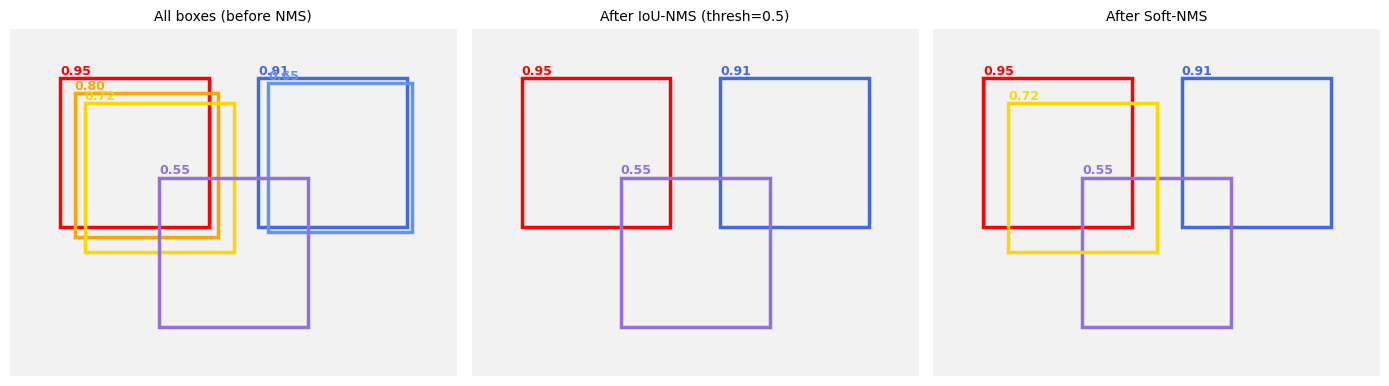

In [8]:
def nms_iou(boxes, scores, iou_thresh=0.5):
    """Standard NMS using IoU threshold."""
    order = scores.argsort(descending=True)
    keep  = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        ious = box_iou_matrix(boxes[i:i+1], boxes[rest])[0]
        order = rest[ious < iou_thresh]
    return keep


def soft_nms(boxes, scores, sigma=0.5, score_thresh=0.3):
    """Soft-NMS: decay scores instead of hard removal (Bodla et al., 2017)."""
    scores = scores.clone().float()
    keep   = []
    for _ in range(len(boxes)):
        i = scores.argmax().item()
        if scores[i] < score_thresh:
            break
        keep.append(i)
        ious = box_iou_matrix(boxes[i:i+1], boxes)[0]
        # Gaussian decay — overlapping boxes get lower scores, not removed
        scores = scores * torch.exp(-ious**2 / sigma)
        scores[i] = 0.0
    return keep


# Demo: crowded scene with 6 overlapping boxes
boxes_nms = torch.tensor([
    [1.,1.,4.,4.], [1.3,1.3,4.2,4.2], [1.5,1.5,4.5,4.5],  # group A (same object)
    [5.,1.,8.,4.], [5.2,1.1,8.1,4.1],                       # group B (same object)
    [3.,3.,6.,6.],                                            # partially overlaps both
])
scores_nms = torch.tensor([0.95, 0.80, 0.72, 0.91, 0.65, 0.55])

kept_iou  = nms_iou(boxes_nms, scores_nms, iou_thresh=0.5)
kept_soft = soft_nms(boxes_nms, scores_nms, sigma=0.5, score_thresh=0.3)

print(f'Original boxes:   {len(boxes_nms)}')
print(f'After IoU-NMS:    {len(kept_iou)}  kept indices: {kept_iou}')
print(f'After Soft-NMS:   {len(kept_soft)} kept indices: {kept_soft}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_all = ['red','orange','gold','royalblue','cornflowerblue','mediumpurple']
for ax, (title, idxs) in zip(axes, [
    ('All boxes (before NMS)', range(len(boxes_nms))),
    (f'After IoU-NMS (thresh=0.5)', kept_iou),
    ('After Soft-NMS', kept_soft)
]):
    canvas = np.ones((700,900,3))*0.95
    ax.imshow(canvas)
    for i in idxs:
        x1,y1,x2,y2 = (boxes_nms[i]*100).int().tolist()
        sc = scores_nms[i].item()
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2.5,
            edgecolor=colors_all[i],facecolor='none'))
        ax.text(x1,y1-8,f'{sc:.2f}',color=colors_all[i],fontsize=9,fontweight='bold')
    ax.set_title(title,fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

## 6. mAP: Mean Average Precision

mAP is the standard metric for object detection. It aggregates precision across all recall levels and all classes.

**Step-by-step computation**:

1. For each class, sort all predicted boxes by **confidence score** (descending)
2. For each prediction, match it to a GT box (greedy, by descending IoU)
   - Match found AND IoU ≥ threshold → **TP**
   - Otherwise → **FP**
   - Unmatched GT → **FN**
3. Compute **cumulative Precision** and **Recall** at each rank
4. **AP** = area under the Precision-Recall curve (11-point interpolation for VOC, or all-points for COCO)
5. **mAP** = mean AP across all classes

**COCO metrics**:
- **AP** = mAP@[0.5:0.05:0.95] — average over 10 IoU thresholds
- **AP50** = mAP@0.5 (loose)
- **AP75** = mAP@0.75 (strict)
- **AP_S/M/L** = AP for small/medium/large objects

<img src='img/precision_recall.png' width='500'/>

AP@0.5 = 1.0000
AP@[0.5:0.95] (COCO) = 0.8556


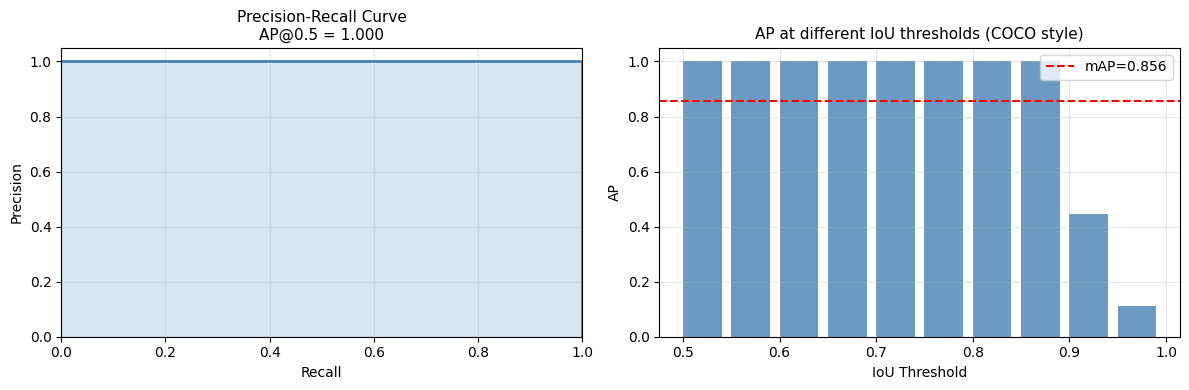

In [9]:
def compute_ap(recalls, precisions):
    """Area under P-R curve using all-points interpolation (COCO style)."""
    # Prepend (0,1) and append (1,0)
    mrec = np.concatenate([[0.0], recalls, [1.0]])
    mpre = np.concatenate([[1.0], precisions, [0.0]])
    # Make precision monotonically decreasing
    for i in range(len(mpre)-2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i+1])
    # Integrate: sum over segments where recall increases
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap  = np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1])
    return ap, mrec, mpre


def compute_map_single_class(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5):
    """
    Compute AP for a single class.
    pred_boxes: (N,4), pred_scores: (N,), gt_boxes: (M,4)
    """
    if len(gt_boxes) == 0:
        return 0.0, [], []

    # Sort by score descending
    order = np.argsort(pred_scores)[::-1]
    pred_boxes  = pred_boxes[order]
    pred_scores = pred_scores[order]

    matched_gt = set()
    tp_list, fp_list = [], []

    for pb in pred_boxes:
        if len(gt_boxes) == 0:
            fp_list.append(1); tp_list.append(0)
            continue

        ious = iou_numpy(pb[None], gt_boxes)
        best_gt = ious.argmax()
        best_iou = ious[best_gt]

        if best_iou >= iou_thresh and best_gt not in matched_gt:
            tp_list.append(1); fp_list.append(0)
            matched_gt.add(best_gt)
        else:
            tp_list.append(0); fp_list.append(1)

    tp = np.cumsum(tp_list).astype(float)
    fp = np.cumsum(fp_list).astype(float)
    n_gt = len(gt_boxes)

    recalls    = tp / (n_gt + 1e-6)
    precisions = tp / (tp + fp + 1e-6)

    ap, mrec, mpre = compute_ap(recalls, precisions)
    return ap, mrec, mpre


# Demo: 8 predictions vs 3 GT boxes
gt_boxes_demo = np.array([[1,1,4,4],[5,1,8,4],[3,5,7,8]], dtype=float)
pred_boxes_demo = np.array([
    [1.1,1.1,4.1,4.1],  # hits GT0
    [5.1,1.0,8.1,4.0],  # hits GT1
    [3.1,5.0,7.1,8.0],  # hits GT2
    [1.5,1.5,4.5,4.5],  # duplicate of GT0 → FP
    [9.0,9.0,11.,11.],  # no match → FP
    [5.0,5.0,7.0,7.0],  # partial GT2 → depends on IoU
    [4.5,0.5,7.5,3.5],  # partial GT1
    [0.0,4.0,2.0,7.0],  # no match
], dtype=float)
pred_scores_demo = np.array([0.95, 0.90, 0.85, 0.78, 0.70, 0.65, 0.55, 0.40])

ap50, rec, prec = compute_map_single_class(
    pred_boxes_demo, pred_scores_demo, gt_boxes_demo, iou_thresh=0.5)
print(f'AP@0.5 = {ap50:.4f}')

# Compute AP at multiple thresholds (COCO style)
aps = []
for thresh in np.arange(0.5, 1.0, 0.05):
    ap, _, _ = compute_map_single_class(pred_boxes_demo, pred_scores_demo, gt_boxes_demo, thresh)
    aps.append(ap)
print(f'AP@[0.5:0.95] (COCO) = {np.mean(aps):.4f}')

# Plot P-R curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].step(rec, prec, where='post', color='steelblue', lw=2)
axes[0].fill_between(rec, prec, alpha=0.2, color='steelblue')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve\nAP@0.5 = {ap50:.3f}', fontsize=11)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.05); axes[0].grid(alpha=0.3)

thresholds = np.arange(0.5, 1.0, 0.05)
axes[1].bar(thresholds, aps, width=0.04, color='steelblue', alpha=0.8, align='edge')
axes[1].axhline(np.mean(aps), color='red', linestyle='--', label=f'mAP={np.mean(aps):.3f}')
axes[1].set_xlabel('IoU Threshold'); axes[1].set_ylabel('AP')
axes[1].set_title('AP at different IoU thresholds (COCO style)', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Summary: IoU Family

| Metric | Formula | Range | Gradient when no overlap | Used for |
|--------|---------|-------|--------------------------|----------|
| **IoU** | $\frac{A \cap B}{A \cup B}$ | [0, 1] | 0 (no signal!) | NMS, mAP evaluation |
| **GIoU** | $\text{IoU} - \frac{C \setminus (A \cup B)}{C}$ | [-1, 1] | Non-zero via C | Box regression loss |
| **DIoU** | $\text{IoU} - \frac{\rho^2}{c^2}$ | [-1, 1] | Non-zero via center dist | Box loss, DIoU-NMS |
| **CIoU** | $\text{DIoU} - \alpha v$ | [-1, 1] | Non-zero | Box loss in YOLO v5/7/8 |

**mAP thresholds in practice**:
- **Pascal VOC**: AP@0.5 (one threshold, simple)
- **COCO**: AP@[0.5:0.05:0.95] (10 thresholds averaged — much stricter)
- **COCO AP50** ≈ **Pascal VOC mAP** in spirit

**Threshold intuition**:
- 0.5: loose — a rough box is fine
- 0.75: strict — need precise localization
- 0.9+: very strict — basically pixel-perfect